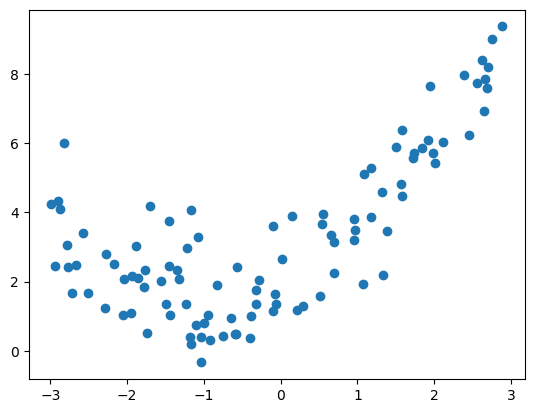

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)
plt.figure()
plt.scatter(X,y)
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import ( train_test_split)
model = LinearRegression()

In [3]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


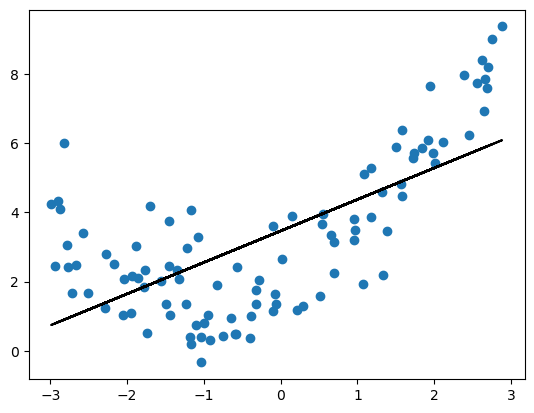

In [4]:
pred = model.intercept_ + model.coef_*X
plt.figure()
plt.scatter(X,y)
plt.plot (X, pred,'k-')

plt.show()

In [5]:
model.score(X,y)

0.4490402711952203

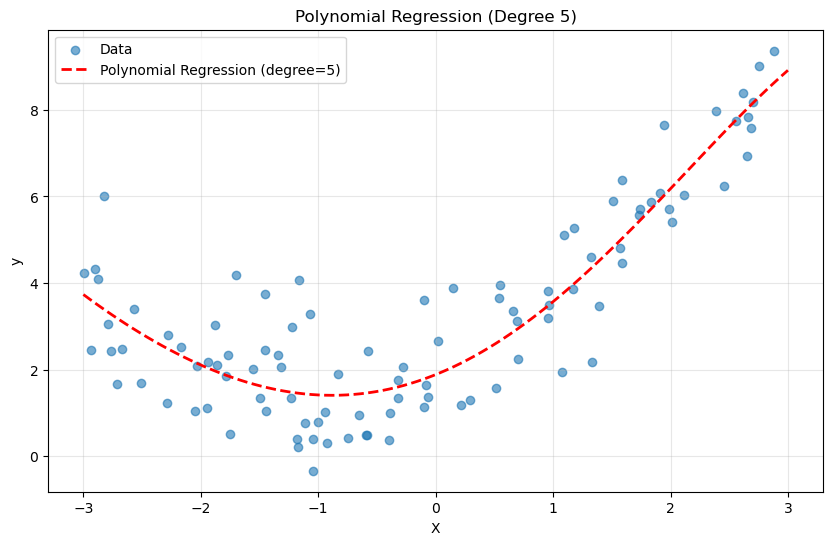

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


pol = PolynomialFeatures(degree=5, include_bias=False)
X_p = pol.fit_transform(X)  

model = LinearRegression()
model.fit(X_p, y)

X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
X_line_p = pol.transform(X_line)  
y_line = model.predict(X_line_p)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_line, y_line, 'r--', linewidth=2, label='Polynomial Regression (degree=5)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression (Degree 5)')
plt.grid(True, alpha=0.3)
plt.show()


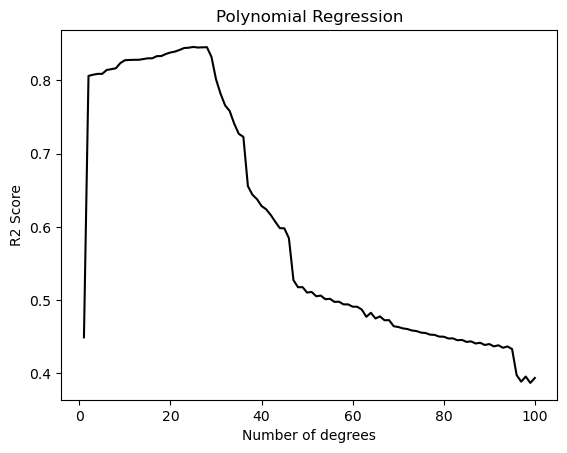

In [7]:
model = LinearRegression()
scores = []
for i in range ( 1,101 ) : 
    polynomial = PolynomialFeatures( degree = i , include_bias = False ) 
    X_p = polynomial.fit_transform(X) 
    model.fit(X_p,y) 
    score = model.score( X_p ,y )
    scores.append(score)

plt.figure() 
plt.plot( range(1,101), scores , color = 'black' , marker = None ) 
plt.xlabel ( 'Number of degrees')
plt.ylabel ( 'R2 Score')
plt.title('Polynomial Regression')
plt.show()


Having multiple degrees is overfitting and might lead to distortion

with high variance leads to low bias

To get how complex the model should be we use the learning curves 

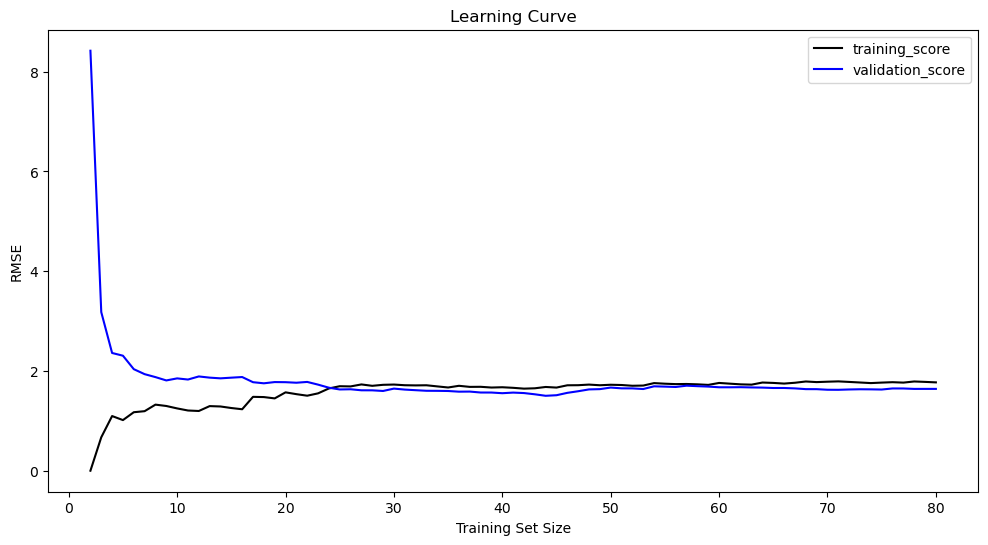

In [24]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

def learning(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
    t_scores, v_scores = [], []

    for i in range(2, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = LinearRegression()
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = (12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


Both training error and test error is high which means underfitting ,Adding more instances wont solve the problem instead a complex model

 Both the training curve (black) and validation curve (blue) flatten out very early (around a training size of 10) and stay completely flat all the way to 80 samples. Adding more data does not help the model learn anything new.

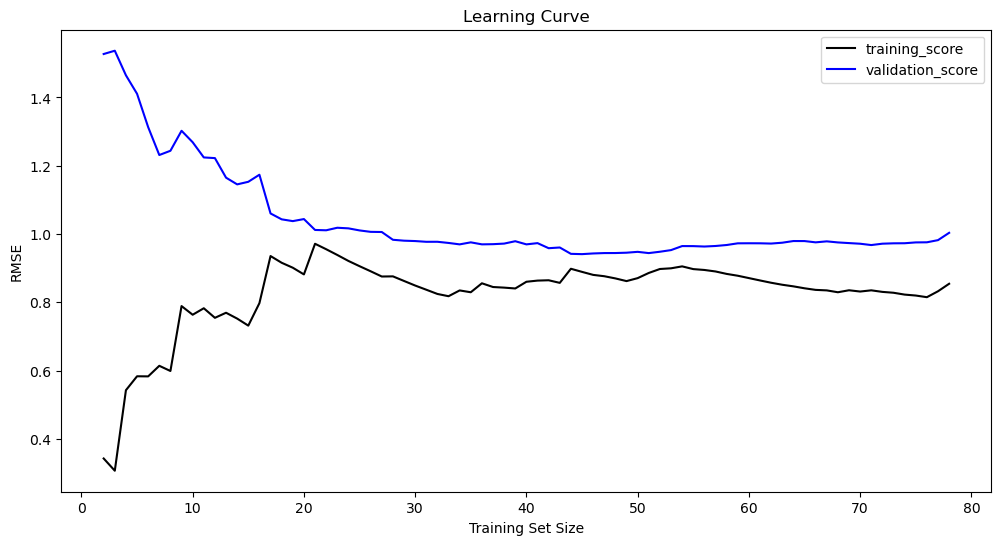

In [23]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 2, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state = 24)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = LinearRegression()
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


The error rate is low in both including the gaps the reason why it is good because as with  more instances the model learns new patterns unlike in the linear regression where it fails to learn anything

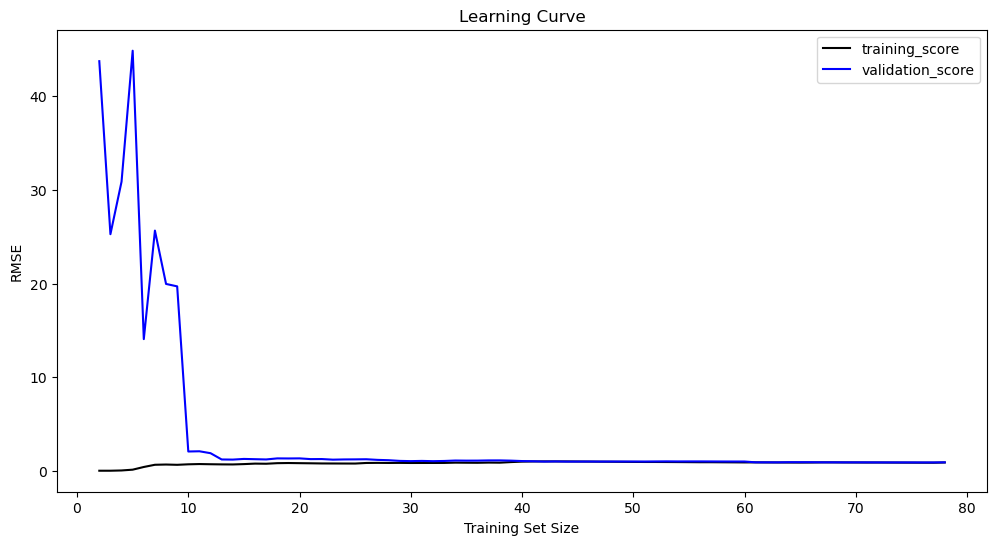

In [27]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 4, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = LinearRegression()
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


Here the model is overfitting 

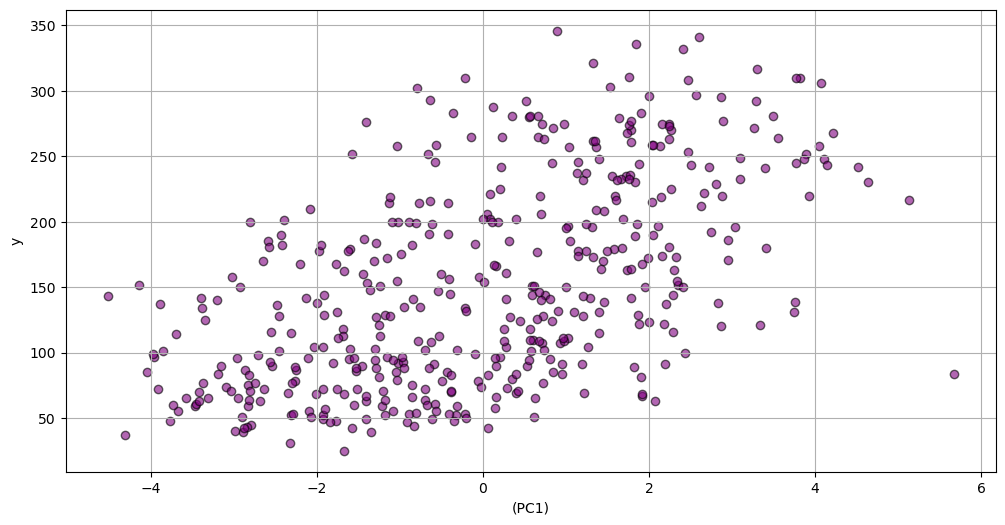

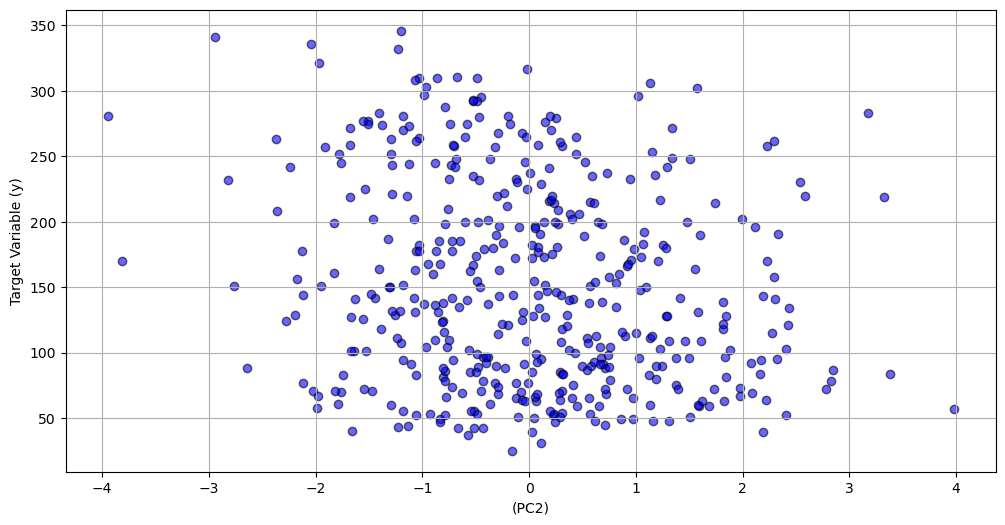

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

diabetes = load_diabetes(as_frame=True, scaled=False)
df = diabetes.frame 
X = df.drop('target', axis=1) 
y = df['target']


pca_pipeline = make_pipeline(StandardScaler(), PCA(n_components=2))
X_pca = pca_pipeline.fit_transform(X)


pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]


plt.figure(figsize=(12, 6))
plt.scatter(pc1, y, color='purple', alpha=0.6, edgecolors='k')
plt.xlabel('(PC1)')
plt.ylabel('y')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(pc2, y, color='blue', alpha=0.6, edgecolors='k')
plt.xlabel('(PC2)')
plt.ylabel('Target Variable (y)')
plt.grid(True)
plt.show()


The diabetic dataset is straight linear and linear regression works well here

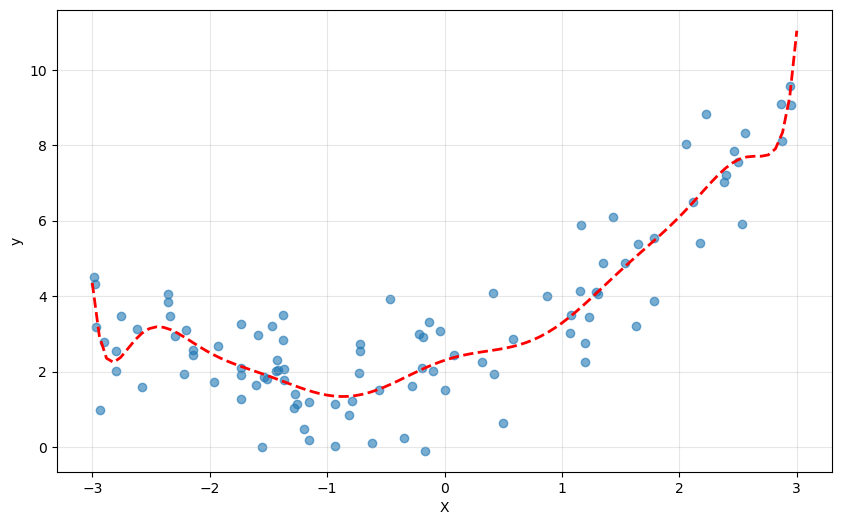

In [12]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)


pol = PolynomialFeatures(degree=12, include_bias=False)
X_p = pol.fit_transform(X)  

model = LinearRegression()
model.fit(X_p, y)

X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
X_line_p = pol.transform(X_line)  
y_line = model.predict(X_line_p)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_line, y_line, 'r--', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
np.round(model.coef_,2)

array([[ 1.03, -1.19, -0.13,  1.93,  0.07, -0.88, -0.02,  0.2 ,  0.  ,
        -0.02, -0.  ,  0.  ]])

Now we add a ridge regression that shrinks the weights towards zero but not zero ,Handles correlated features by spreading the weight evenly.

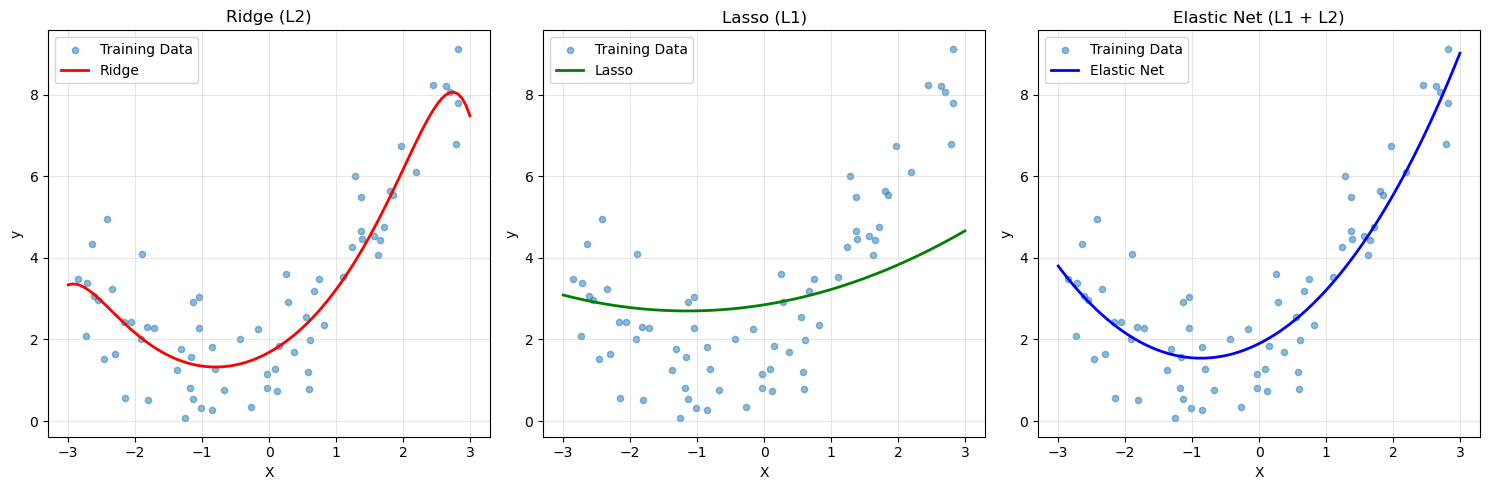

COEFFICIENTS (Degree 10 Polynomial)
Term       Ridge        Lasso        Elastic Net 
------------------------------------------------------------
X^1      1.5082       0.4366       1.3710      
X^2      1.5161       0.2937       1.2282      
X^3      0.3131       0.0000       0.0489      
X^4      0.2489       0.0000       0.0545      
X^5      -0.0412      0.0000       0.0000      
X^6      -0.0411      0.0000       0.0000      
X^7      -0.1205      0.0000       0.0000      
X^8      -0.1462      0.0000       0.0000      
X^9      -0.1497      0.0000       -0.0000     
X^10     -0.2297      0.0000       -0.0000     

Non-zero coefficients:
  Ridge: 10
  Lasso: 2
  Elastic Net: 4


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)

lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])
lasso_pipeline.fit(X_train, y_train)

elastic_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
])
elastic_pipeline.fit(X_train, y_train)


X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
y_ridge = ridge_pipeline.predict(X_line)
y_lasso = lasso_pipeline.predict(X_line)
y_elastic = elastic_pipeline.predict(X_line)


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training Data')
plt.plot(X_line, y_ridge, 'r-', linewidth=2, label='Ridge')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Ridge (L2)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training Data')
plt.plot(X_line, y_lasso, 'g-', linewidth=2, label='Lasso')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Lasso (L1)')
plt.grid(True, alpha=0.3)


plt.subplot(1, 3, 3)
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training Data')
plt.plot(X_line, y_elastic, 'b-', linewidth=2, label='Elastic Net')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Elastic Net (L1 + L2)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ridge_coefs = ridge_pipeline.named_steps['ridge'].coef_.flatten()
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_.flatten()
elastic_coefs = elastic_pipeline.named_steps['elastic'].coef_.flatten()

print("="*60)
print("COEFFICIENTS (Degree 10 Polynomial)")
print("="*60)
print(f"{'Term':<10} {'Ridge':<12} {'Lasso':<12} {'Elastic Net':<12}")
print("-"*60)
for i in range(10):
    print(f"X^{i+1:<6} {ridge_coefs[i]:<12.4f} {lasso_coefs[i]:<12.4f} {elastic_coefs[i]:<12.4f}")

print(f"\nNon-zero coefficients:")
print(f"  Ridge: {np.sum(np.abs(ridge_coefs) > 1e-6)}")
print(f"  Lasso: {np.sum(np.abs(lasso_coefs) > 1e-6)}")
print(f"  Elastic Net: {np.sum(np.abs(elastic_coefs) > 1e-6)}")

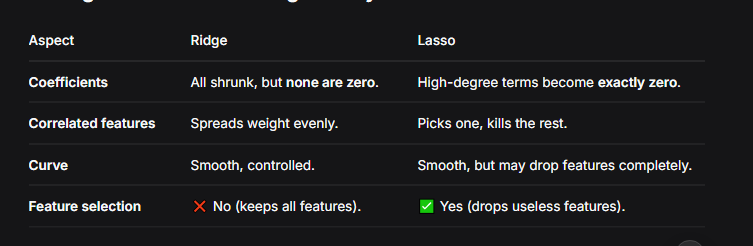

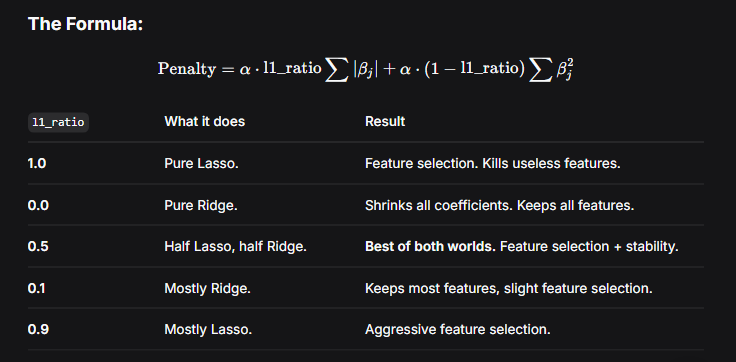

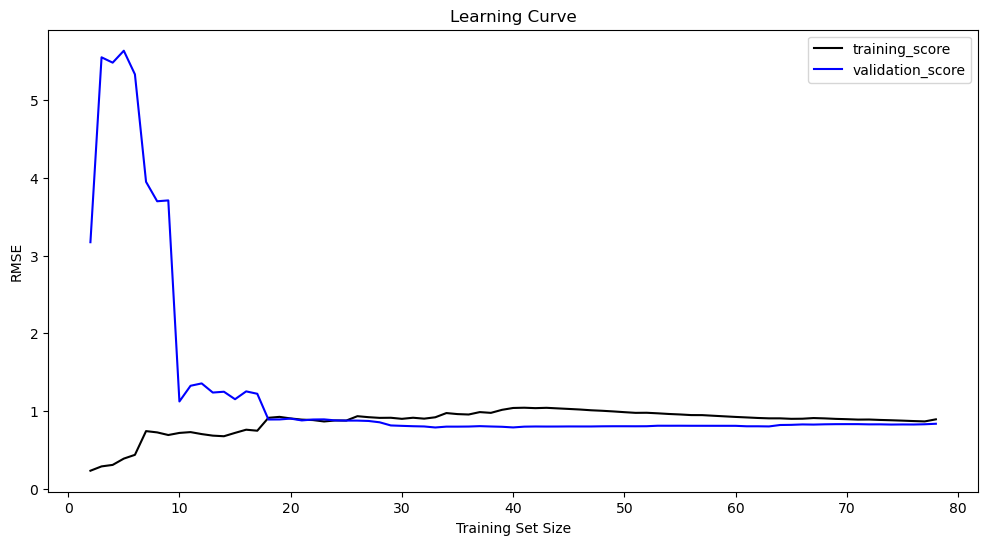

In [35]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 3, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = Ridge(2)
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


Ridge added penalty for coeffecients to be very bigger and made them smaller now the model is good fit

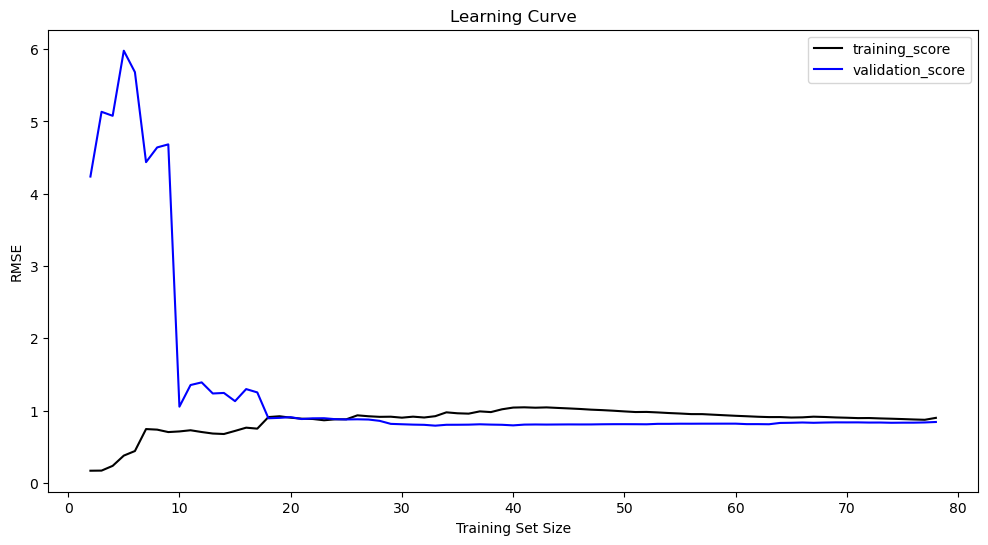

In [41]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 3, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = Lasso(0.05)
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()
